## **SPLIT OPERATOR FOURIER TRANSFORMATION**

In [1]:
#inisialisasi wave packet

import numpy as np

def psi0(x, p0, x0):
    #generate the intiial wave function (psi0)
    y = (1/ np.pi)**(0.25)*np.exp(-1*(1/2)*((x-x0)**2)+1j*p0*x)
    return y

N =  64
xmax = 5
xmin = -5
x0 = 1
p0 = 0
mass = 1
omega = 1
hbar = 1
dx = (xmax-xmin)/N
dp = 2*np.pi/(xmax-xmin)
pv = np.asarray([p0 + (j - N/2) * dp for j in range(N)])
xv = np.asarray([(j - N/2) * dx for j in range(N)])
psio = psi0(xv, p0, x0)

In [2]:
#SOFT Operators for Harmonic Oscillator
import scipy.linalg as spLA

def harmonic(xgrid, mass, omega):
    #this function generates a 1D harmonic oscillator potential
    pot = 0.5*mass*(omega**2)*(xgrid**2)
    return pot

Nsteps = 500                #number of time steps
total_time = 20             #total propagation time
tau = total_time/Nsteps     #time step

#potential energy
V_ho = harmonic(xv, mass, omega)
V_prop = np.exp(-1j/hbar * V_ho * tau/2)

#kinetic energy
pv_fft  = np.fft.fftfreq(N, d=dx) * 2 * np.pi   # ← urutan sesuai fft()
KE_ho   = pv_fft**2 / (2 * mass)
KE_prop = np.exp(-1j * hbar * KE_ho * tau)


In [3]:
#SOFT Propagation for a single time step
def soft(psi, pot_prop, kin_prop):
    out = pot_prop * psi        #potential energy propagation
    out = kin_prop*np.fft.fft(out) #kinetic energy propagation
    out = pot_prop * np.fft.ifft(out) #potential energy propagation
    return out  

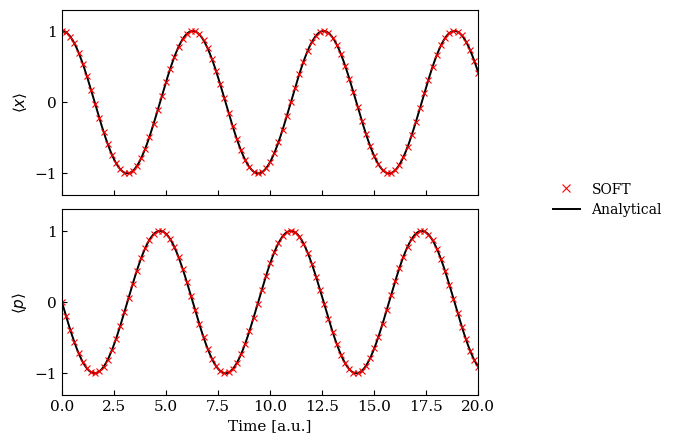

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

#expectation value helpers
def expect_x(psi):
    prob = np.abs(psi)**2
    return np.sum(xv * prob) * dx / (np.sum(prob) * dx)

def expect_p(psi):
    # Turunan spektral: p̂ψ = IFFT(hbar * pv_fft * FFT(ψ))
    p_psi = np.fft.ifft(hbar * pv_fft * np.fft.fft(psi))
    norm  = np.sum(np.abs(psi)**2) * dx
    return np.real(np.sum(np.conj(psi) * p_psi) * dx) / norm

#run simulation
psi    = psio.copy()
times  = np.linspace(0, total_time, Nsteps + 1)

x_soft = np.zeros(Nsteps + 1)
p_soft = np.zeros(Nsteps + 1)

x_soft[0] = expect_x(psi)
p_soft[0]  = expect_p(psi)

for i in range(1, Nsteps + 1):
    psi        = soft(psi, V_prop, KE_prop)
    x_soft[i]  = expect_x(psi)
    p_soft[i]  = expect_p(psi)

#solusi analitik
x_anal = x0 * np.cos(omega * times)
p_anal = -mass * omega * x0 * np.sin(omega * times)

#plot
mpl.rcParams.update({'font.family': 'serif', 'font.size': 11,
                     'axes.linewidth': 0.8,
                     'xtick.direction': 'in', 'ytick.direction': 'in'})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
fig.subplots_adjust(hspace=0.08, right=0.72)

stride = 5  # tipiskan jumlah marker x

ax1.plot(times, x_anal, 'k-', lw=1.4)
ax1.plot(times[::stride], x_soft[::stride], 'rx', ms=4, mew=0.8)
ax1.set_ylabel(r'$\langle x \rangle$')
ax1.set_ylim(-1.3, 1.3);  ax1.set_yticks([-1, 0, 1])
ax1.tick_params(labelbottom=False)

ax2.plot(times, p_anal, 'k-', lw=1.4)
ax2.plot(times[::stride], p_soft[::stride], 'rx', ms=4, mew=0.8)
ax2.set_ylabel(r'$\langle p \rangle$')
ax2.set_xlabel('Time [a.u.]')
ax2.set_ylim(-1.3, 1.3);  ax2.set_yticks([-1, 0, 1])
ax2.set_xlim(0, total_time)

handles = [
    mpl.lines.Line2D([0],[0], marker='x', color='r', linestyle='None',
                     markersize=6, markeredgewidth=0.8, label='SOFT'),
    mpl.lines.Line2D([0],[0], color='k', lw=1.4, label='Analytical'),
]
fig.legend(handles=handles, loc='center right',
           bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=10)

plt.show()

## **QuTiP Method**

In [5]:
import qutip as qt

#define number of states in fock basis
N = 128
a = qt.destroy(N)       #define annihilation operator

#define the initial state
xo = 1      #initial position
po = 0      #initial momentum

#define coherent state with amplitudo alpha
psi0 = qt.coherent(N, alpha=(xo+1j*po)/np.sqrt(2))

#define the hamitonian
mass = 1
hbar = 1
omga = 1
H_ho = hbar*omga*(a.dag()*a + 1/2)      #harmonic oscilator hamiltonian

#define the propagation time array with n_steps from 0 to total_time
n_steps = 500
total_time = 20

#define the list of times to evaluate the state
tlist = np.linspace(0, total_time, n_steps)

#run dynamics
result = qt.mesolve(H_ho, psi0, tlist, [], [], progress_bar=True, options=qt.solver.Options(nsteps=len(tlist)))


10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.01s. Est. time left: 00:00:00:00
30.1%. Run time:   0.03s. Est. time left: 00:00:00:00
40.1%. Run time:   0.04s. Est. time left: 00:00:00:00
50.1%. Run time:   0.05s. Est. time left: 00:00:00:00
60.1%. Run time:   0.06s. Est. time left: 00:00:00:00
70.1%. Run time:   0.07s. Est. time left: 00:00:00:00
80.2%. Run time:   0.08s. Est. time left: 00:00:00:00
90.2%. Run time:   0.09s. Est. time left: 00:00:00:00
100.0%. Run time:   0.10s. Est. time left: 00:00:00:00
Total run time:   0.11s


/mgpfs/home/nhandayani/.conda/envs/mycenvn/lib/python3.10/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/mgpfs/home/nhandayani/.conda/envs/mycenvn/lib/python3.10/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/mgpfs/home/nhandayani/.conda/envs/mycenvn/lib/python3.10/site-packages/qutip/solver/solver_base.py:501: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


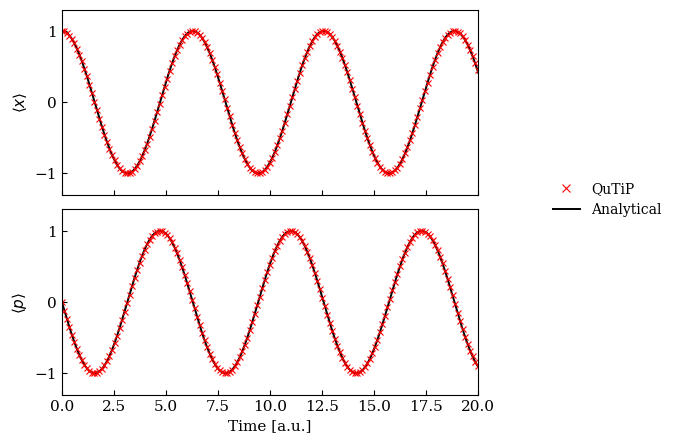

In [6]:
#operator posisi dan momentum
x_op = (a + a.dag()) / np.sqrt(2)          # x̂ = (a + a†) / √2
p_op = 1j * (a.dag() - a) / np.sqrt(2)     # p̂ = i(a† - a) / √2

#hitung nilai ekspektasi dari hasil simulasi
x_qutip = qt.expect(x_op, result.states)   # ⟨x⟩ tiap waktu
p_qutip = qt.expect(p_op, result.states)   # ⟨p⟩ tiap waktu

#solusi analitik
x_anal = xo * np.cos(omga * tlist)
p_anal = -mass * omga * xo * np.sin(omga * tlist)

#plot
mpl.rcParams.update({'font.family': 'serif', 'font.size': 11,
                     'axes.linewidth': 0.8,
                     'xtick.direction': 'in', 'ytick.direction': 'in'})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
fig.subplots_adjust(hspace=0.08, right=0.72)

stride = 3

ax1.plot(tlist, x_anal, 'k-', lw=1.4)
ax1.plot(tlist[::stride], x_qutip[::stride], 'rx', ms=4, mew=0.8)
ax1.set_ylabel(r'$\langle x \rangle$')
ax1.set_ylim(-1.3, 1.3);  ax1.set_yticks([-1, 0, 1])
ax1.tick_params(labelbottom=False)

ax2.plot(tlist, p_anal, 'k-', lw=1.4)
ax2.plot(tlist[::stride], p_qutip[::stride], 'rx', ms=4, mew=0.8)
ax2.set_ylabel(r'$\langle p \rangle$')
ax2.set_xlabel('Time [a.u.]')
ax2.set_ylim(-1.3, 1.3);  ax2.set_yticks([-1, 0, 1])
ax2.set_xlim(0, total_time)

handles = [
    mpl.lines.Line2D([0],[0], marker='x', color='r', linestyle='None',
                     markersize=6, markeredgewidth=0.8, label='QuTiP'),
    mpl.lines.Line2D([0],[0], color='k', lw=1.4, label='Analytical'),
]
fig.legend(handles=handles, loc='center right',
           bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=10)

plt.show()